In [11]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from openpyxl.formatting.rule import ColorScaleRule, FormulaRule
import numpy as np
from openpyxl.styles import numbers
!pip install xlsxwriter

In [12]:
datos = pd.read_excel("/content/Exportación Pre- Semana 26 (1).xlsx")

In [13]:
def clean_numeric_column(series):
    """
    Detecta y normaliza formatos mixtos:
    - 1.234,56
    - 1,234.56
    - € 1.234
    - strings con %
    """

    def convert(x):
        if pd.isna(x):
            return np.nan

        x = str(x).strip()

        # quitar símbolos de moneda y espacios raros
        x = re.sub(r"[€$%]", "", x)
        x = x.replace(" ", "")

        # detectar formato europeo 1.234,56
        if "," in x and "." in x:
            if x.rfind(",") > x.rfind("."):
                x = x.replace(".", "").replace(",", ".")
            else:
                x = x.replace(",", "")

        # formato solo coma decimal
        elif "," in x and "." not in x:
            x = x.replace(",", ".")

        try:
            return float(x)
        except:
            return np.nan

    return series.apply(convert)


# columnas que quieres normalizar
cols = ["Index", "Sales", "Margin €", "Margin %"]

for col in cols:
    datos[col] = clean_numeric_column(datos[col])

In [14]:


# =====================================================
# 0. FUNCIÓN LIMPIEZA NUMÉRICA
# =====================================================
def clean_eu_number(x):
    if pd.isna(x):
        return None

    if isinstance(x, str):
        x = x.replace("€", "").replace("%", "").strip()

        # formato europeo: 1.234.567,89
        if "," in x and "." in x:
            x = x.replace(".", "").replace(",", ".")
        else:
            x = x.replace(",", ".")

    try:
        return float(x)
    except:
        return None


# =====================================================
# 1. TABLA KPI DETALLE
# =====================================================
orden_estado = ["Inicial", "Simulado", "Brecha"]

kpis = datos[
    datos["Mercado"].notna() & datos["Categoría"].isna()
][[
    "Mercado",
    "Estado",
    "Product Nb",
    "Index",
    "Margin €",
    "Margin %",
    "Sales"
]].copy()

# -------------------------
# LIMPIEZA KPI
# -------------------------
for col in ["Margin €", "Sales", "Index"]:
    kpis[col] = kpis[col].apply(clean_eu_number)

kpis["Margin %"] = kpis["Margin %"].apply(clean_eu_number)

# normalizar %
if kpis["Margin %"].max() > 1:
    kpis["Margin %"] = kpis["Margin %"] / 100

kpis["Estado"] = pd.Categorical(
    kpis["Estado"],
    categories=orden_estado,
    ordered=True
)

kpis = (
    kpis.sort_values(["Mercado", "Estado"])
    .reset_index(drop=True)
)


# =====================================================
# 2. TABLA RESUMEN
# =====================================================
df = datos[
    datos["Mercado"].notna() & datos["Categoría"].isna()
].copy()

for col in ["Margin €", "Sales", "Index"]:
    df[col] = df[col].apply(clean_eu_number)

resultado = (
    df.groupby("Estado")
    .agg(
        Index_media=("Index", "mean"),
        Index_mediana=("Index", "median"),
        Sales=("Sales", "sum"),
        Margin_eur=("Margin €", "sum")
    )
    .reset_index()
)

resultado["Margin %"] = resultado["Margin_eur"] / resultado["Sales"]

# seguridad %
if resultado["Margin %"].max() > 1:
    resultado["Margin %"] = resultado["Margin %"] / 100

resultado["Estado"] = pd.Categorical(
    resultado["Estado"],
    categories=orden_estado,
    ordered=True
)

resultado = resultado.sort_values("Estado").reset_index(drop=True)


# =====================================================
# 3. EXPORTAR EXCEL (2 TABLAS LADO A LADO)
# =====================================================
excel_file = "resumen_kpis_resultados.xlsx"

kpi_start_col = 0
res_start_col = len(kpis.columns) + 2  # separación entre tablas

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

    kpis.to_excel(
        writer,
        sheet_name="Resumen",
        startrow=0,
        startcol=kpi_start_col,
        index=False
    )

    resultado.to_excel(
        writer,
        sheet_name="Resumen",
        startrow=0,
        startcol=res_start_col,
        index=False
    )


# =====================================================
# 4. FORMATO EXCEL (CORREGIDO Y ROBUSTO)
# =====================================================
wb = load_workbook(excel_file)
ws = wb["Resumen"]

euro_format = '#,##0.00 "€"'
pct_format = '0.00%'

# -------------------------
# POSICIONES FIJAS
# -------------------------
kpi_col_map = {col: i + 1 for i, col in enumerate(kpis.columns)}
res_col_map = {col: res_start_col + i + 1 for i, col in enumerate(resultado.columns)}

# -------------------------
# KPI IZQUIERDA
# -------------------------
for row in range(2, len(kpis) + 2):

    ws.cell(row, kpi_col_map["Margin €"]).number_format = euro_format
    ws.cell(row, kpi_col_map["Sales"]).number_format = euro_format
    ws.cell(row, kpi_col_map["Margin %"]).number_format = pct_format


# -------------------------
# RESUMEN DERECHA
# -------------------------
for row in range(2, len(resultado) + 2):

    ws.cell(row, res_col_map["Sales"]).number_format = euro_format
    ws.cell(row, res_col_map["Margin_eur"]).number_format = euro_format
    ws.cell(row, res_col_map["Margin %"]).number_format = pct_format


# =====================================================
# 5. AJUSTE COLUMNAS
# =====================================================
for column in ws.columns:
    max_length = 0
    col_letter = column[0].column_letter

    for cell in column:
        if cell.value is not None:
            max_length = max(max_length, len(str(cell.value)))

    ws.column_dimensions[col_letter].width = max_length + 2


# =====================================================
# 6. GUARDAR
# =====================================================
wb.save(excel_file)

print("Excel generado correctamente con formatos % y € arreglados.")

Excel generado correctamente con formatos % y € arreglados.


# Gradiente por Margen

In [15]:
excel_file = "resumen_kpis_resultados.xlsx"
wb = load_workbook(excel_file)

df_base = datos.copy()

# ---------------------------
# 1. LIMPIEZA REAL DE DATOS
# ---------------------------
def clean_number(x):
    if isinstance(x, str):
        x = x.replace("€", "").replace("%", "").strip()

        # formato europeo 1.234,56
        if "," in x and "." in x:
            x = x.replace(".", "").replace(",", ".")
        else:
            x = x.replace(",", ".")

        try:
            return float(x)
        except:
            return x

    return x


df_base["Margin €"] = df_base["Margin €"].apply(clean_number)
df_base["Sales"] = df_base["Sales"].apply(clean_number)
df_base["Margin %"] = df_base["Margin %"].apply(clean_number)
df_base["Index"] = pd.to_numeric(df_base["Index"], errors="coerce")

In [16]:

# ---------------------------
# 2. ORDEN LÓGICO
# ---------------------------
estado_order = {"Inicial": 0, "Simulado": 1, "Brecha": 2}

df_base["Familia_num"] = (
    df_base["Familia"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df_base["Estado_order"] = df_base["Estado"].map(estado_order)

In [17]:
# ---------------------------
# 3. ESCALA INDEX (>0.5 SOLO BRECHA)
# ---------------------------
vals_index = df_base[
    (df_base["Estado"] == "Brecha") &
    (df_base["Index"].notna()) &
    (df_base["Index"] > 0.5)
]["Index"]

if len(vals_index) > 0:
    vmin_i = np.percentile(vals_index, 5)
    vmax_i = np.percentile(vals_index, 95)
else:
    vmin_i, vmax_i = 0, 1

color_scale_index = ColorScaleRule(
    start_type='num',
    start_value=vmin_i,
    start_color='FFFFFF',
    end_type='num',
    end_value=vmax_i,
    end_color='FFA500'
)

In [18]:

# ---------------------------
# 4. ESCALA MARGIN %
# ---------------------------
vals_margin = df_base["Margin %"].dropna()

vmin_m = np.percentile(vals_margin, 5)
vmax_m = np.percentile(vals_margin, 95)

vmin_m = min(vmin_m, 0)
vmax_m = max(vmax_m, 0)

color_scale_margin = ColorScaleRule(
    start_type='num',
    start_value=vmin_m,
    start_color='F8696B',
    mid_type='num',
    mid_value=0,
    mid_color='FFFFFF',
    end_type='num',
    end_value=vmax_m,
    end_color='63BE7B'
)


In [19]:
# ---------------------------
# 5. EXPORTACIÓN POR HOJAS
# ---------------------------
for mercado in sorted(df_base["Mercado"].dropna().unique()):

    nombre_hoja = str(mercado)[:31]

    if nombre_hoja in wb.sheetnames:
        del wb[nombre_hoja]

    mercado_df = (
        df_base[df_base["Mercado"] == mercado]
        [["Mercado", "Categoría", "Familia", "Estado", "Product Nb",
          "Index", "Margin €", "Margin %", "Sales",
          "Familia_num", "Estado_order"]]
        .sort_values([
            "Categoría",
            "Familia_num",
            "Estado_order",
            "Margin %"
        ])
        .drop(columns=["Familia_num", "Estado_order"])
    )

    ws = wb.create_sheet(title=nombre_hoja)
    # ---------------------------
    # HEADERS
    # ---------------------------
    for col_num, col_name in enumerate(mercado_df.columns, start=1):
        ws.cell(row=1, column=col_num, value=col_name)

    # ---------------------------
    # DATA
    # ---------------------------
    for row_num, row in enumerate(mercado_df.itertuples(index=False), start=2):
        for col_num, value in enumerate(row, start=1):
            ws.cell(row=row_num, column=col_num, value=value)

    # ---------------------------
    # COLUMNAS
    # ---------------------------
    headers = {cell.value: cell.column for cell in ws[1]}

    col_estado = headers["Estado"]
    col_margin = headers["Margin %"]
    col_margin_eur = headers["Margin €"]
    col_sales = headers["Sales"]
    col_index = headers["Index"]

    margin_letter = ws.cell(row=1, column=col_margin).column_letter
    index_letter = ws.cell(row=1, column=col_index).column_letter

    # ---------------------------
    # FORMATO CONDICIONAL MARGIN €
    # ---------------------------
    for row in range(2, ws.max_row + 1):

        estado = ws.cell(row=row, column=col_estado).value
        margin_eur = ws.cell(row=row, column=col_margin_eur).value

        if estado == "Brecha" and margin_eur is not None and margin_eur <= -100:

            ws.conditional_formatting.add(
                f"{margin_letter}{row}",
                color_scale_margin
            )

    # ---------------------------
    # INDEX SOLO BRECHA
    # ---------------------------
    for row in range(2, ws.max_row + 1):

        if ws.cell(row=row, column=col_estado).value == "Brecha":

            ws.conditional_formatting.add(
                f"{index_letter}{row}",
                color_scale_index
            )

    # ---------------------------
    # FORMATO VISUAL (€, %)
    # ---------------------------
    euro_format = '#,##0.00 "€"'
    pct_format = '0.00%'

    for row in range(2, ws.max_row + 1):

        ws.cell(row=row, column=col_margin_eur).number_format = euro_format
        ws.cell(row=row, column=col_sales).number_format = euro_format
        ws.cell(row=row, column=col_margin).number_format = pct_format

# ---------------------------
# 6. GUARDAR
# ---------------------------
wb.save(excel_file)

print("OK: Excel limpio + formatos €/% + Index >0.5 + reglas aplicadas correctamente.")

OK: Excel limpio + formatos €/% + Index >0.5 + reglas aplicadas correctamente.


#Grafos

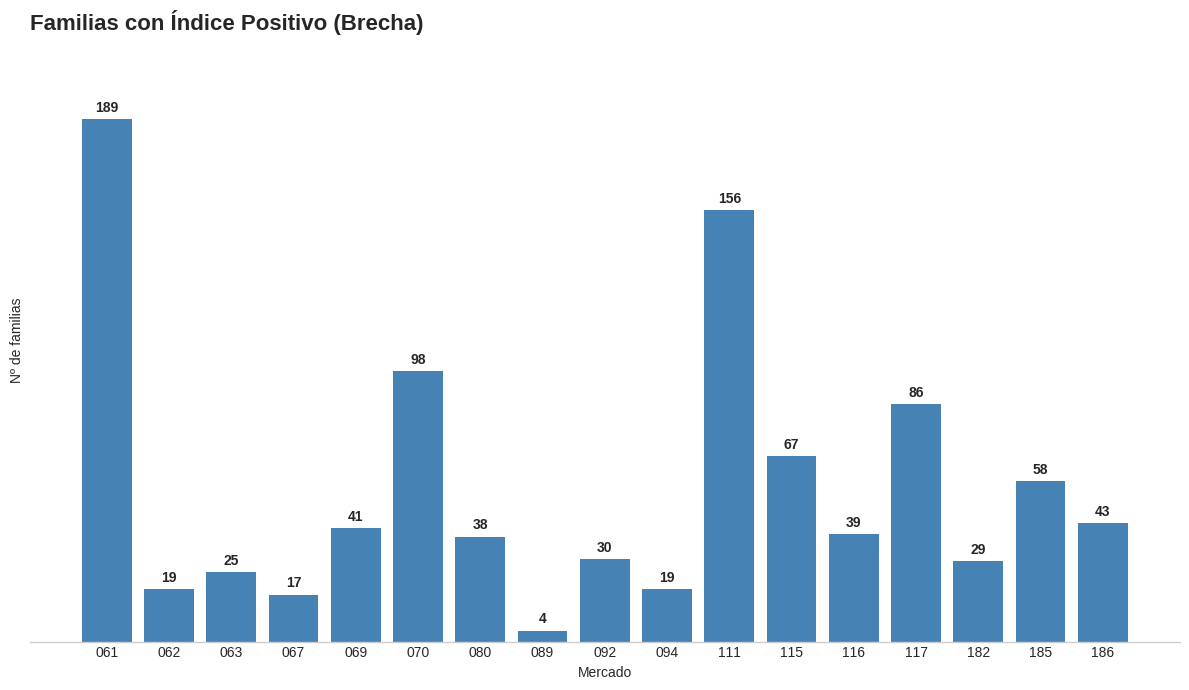

In [20]:
# =====================================================
# 1. LIMPIEZA
# =====================================================
df = datos.copy()
df["Index"] = pd.to_numeric(df["Index"], errors="coerce")

# =====================================================
# 2. KPI
# =====================================================
kpi_index_pos = (
    df[
        (df["Estado"] == "Brecha") &
        (df["Index"] > 0)
    ]
    .groupby("Mercado")["Familia"]
    .nunique()
    .reset_index(name="Familias_Indice_Positivo")
)

# =====================================================
# 3. LIMPIEZA DE MERCADO
# =====================================================
kpi_index_pos["Mercado"] = (
    kpi_index_pos["Mercado"]
    .astype(str)
    .str.extract(r"^(\d{3})")[0]
)

# =====================================================
# 4. GRÁFICO
# =====================================================
plt.style.use('seaborn-v0_8-whitegrid')

fig_index_pos, ax = plt.subplots(figsize=(12, 7))

ax.grid(False)

bars = ax.bar(
    kpi_index_pos["Mercado"],
    kpi_index_pos["Familias_Indice_Positivo"],
    color='#4682B4'
)

# Etiquetas sobre las barras
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.0f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Estética
ax.set_title(
    "Familias con Índice Positivo (Brecha)",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

ax.set_ylabel("Nº de familias")
ax.set_xlabel("Mercado")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.tick_params(axis='y', labelleft=False)

ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.savefig('fig_index_pos.png')
plt.show()

In [21]:
# =====================================================
# % KPI (sin recalcular el numerador)
# =====================================================

# Total de familias por mercado (denominador)
total_familias = (
    df.groupby("Mercado")["Familia"]
    .unique()
    .reset_index(name="Total_Familias")
)


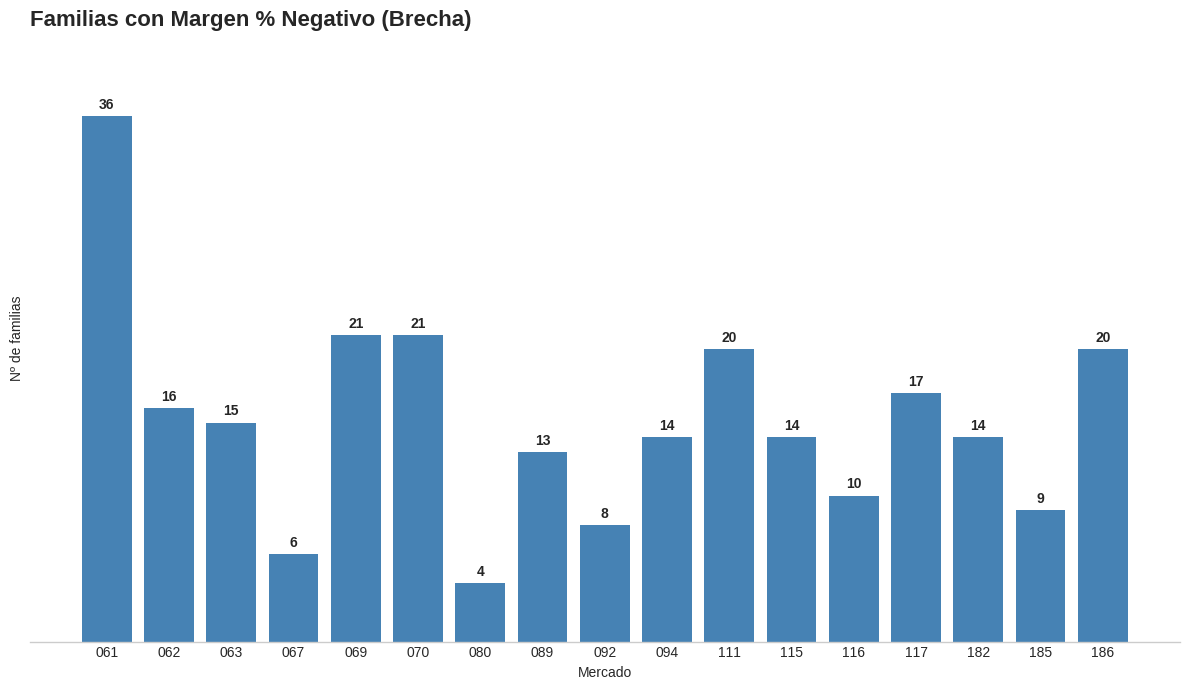

In [22]:

# =====================================================
# 1. LIMPIEZA
# =====================================================
df = datos.copy()
df["Margin %"] = pd.to_numeric(df["Margin %"], errors="coerce")

# =====================================================
# 2. KPI (MISMO PATRÓN QUE kpi_final)
# =====================================================
kpi_margin_neg = (
    df[
        (df["Estado"] == "Brecha") &
        (df["Margin %"] < 0)
    ]
    .groupby("Mercado")["Familia"]
    .nunique()
    .reset_index(name="Familias_Margen_Negativo")
)

# =====================================================
# 3. LIMPIEZA DE MERCADO (solo código 3 dígitos)
# =====================================================
kpi_margin_neg["Mercado"] = (
    kpi_margin_neg["Mercado"]
    .astype(str)
    .str.extract(r"^(\d{3})")[0]
)

# =====================================================
# 4. GRÁFICO (MISMO FORMATO QUE TU KPI BUENO)
# =====================================================
plt.style.use('seaborn-v0_8-whitegrid')

fig_neg_margin, ax2 = plt.subplots(figsize=(12, 7))

ax2.grid(False)

bars = ax2.bar(
    kpi_margin_neg["Mercado"],
    kpi_margin_neg["Familias_Margen_Negativo"],
    color='#4682B4'
)

# -----------------------------------------------------
# Etiquetas sobre barras
# -----------------------------------------------------
for bar in bars:
    height = bar.get_height()
    ax2.annotate(
        f'{height:.0f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# -----------------------------------------------------
# Estética (IGUAL A TU OTRO GRÁFICO)
# -----------------------------------------------------
ax2.set_title(
    "Familias con Margen % Negativo (Brecha)",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

ax2.set_ylabel("Nº de familias")
ax2.set_xlabel("Mercado")

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.tick_params(axis='y', labelleft=False)

ax2.set_ylim(top=ax2.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.savefig('fig_neg_margin.png')
plt.show()

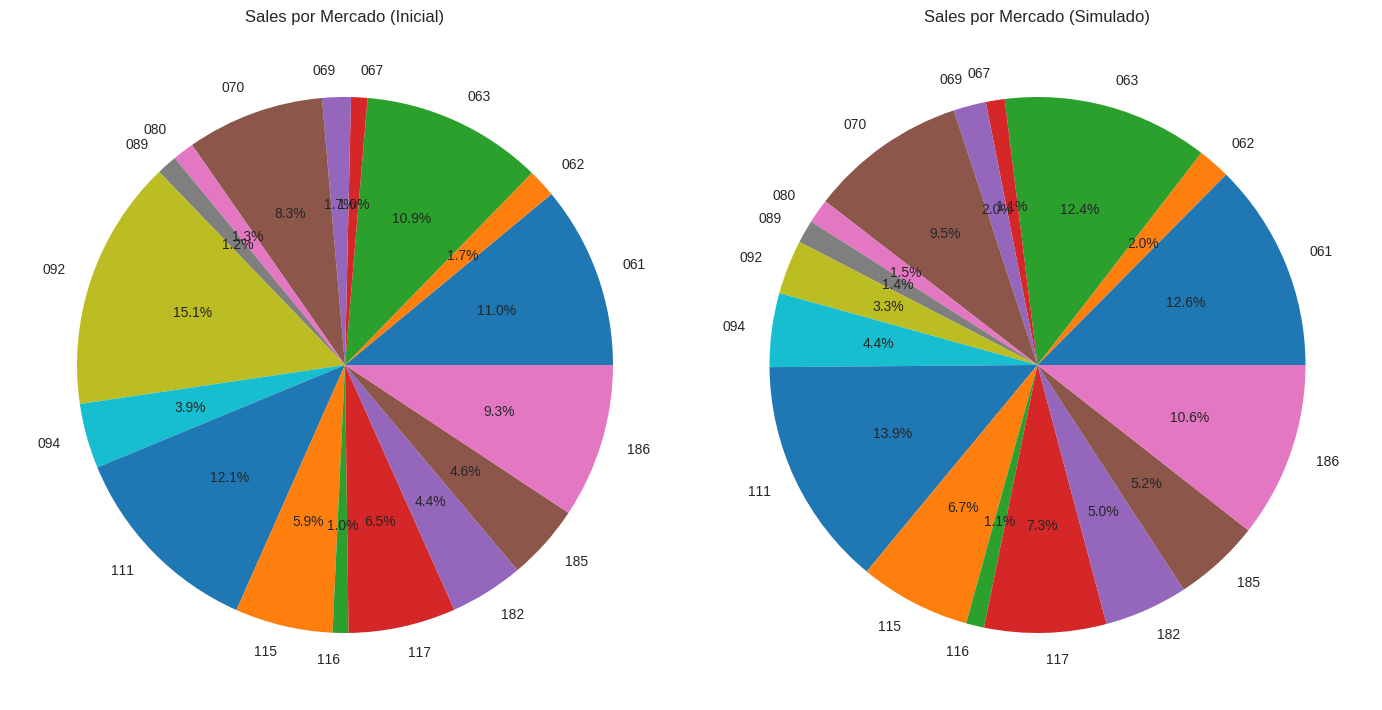

In [23]:
# --- Datos ---
sales_simulado = (
    df[df["Estado"] == "Simulado"]
    .groupby("Mercado")["Sales"]
    .sum()
    .abs()
)

sales_inicial = (
    df[df["Estado"] == "Inicial"]
    .groupby("Mercado")["Sales"]
    .sum()
    .abs()
)

# --- Figura con 2 gráficos lado a lado ---
fig_sales_merc, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Izquierda: Inicial ---
axes[0].pie(
    sales_inicial,
    labels=sales_inicial.index.str.extract(r"^(\d{3})")[0],
    autopct="%1.1f%%"
)
axes[0].set_title("Sales por Mercado (Inicial)")

# --- Derecha: Simulado ---
axes[1].pie(
    sales_simulado,
    labels=sales_simulado.index.str.extract(r"^(\d{3})")[0],
    autopct="%1.1f%%"
)
axes[1].set_title("Sales por Mercado (Simulado)")

plt.tight_layout()
plt.savefig('fig_sales_merc.png')
plt.show()

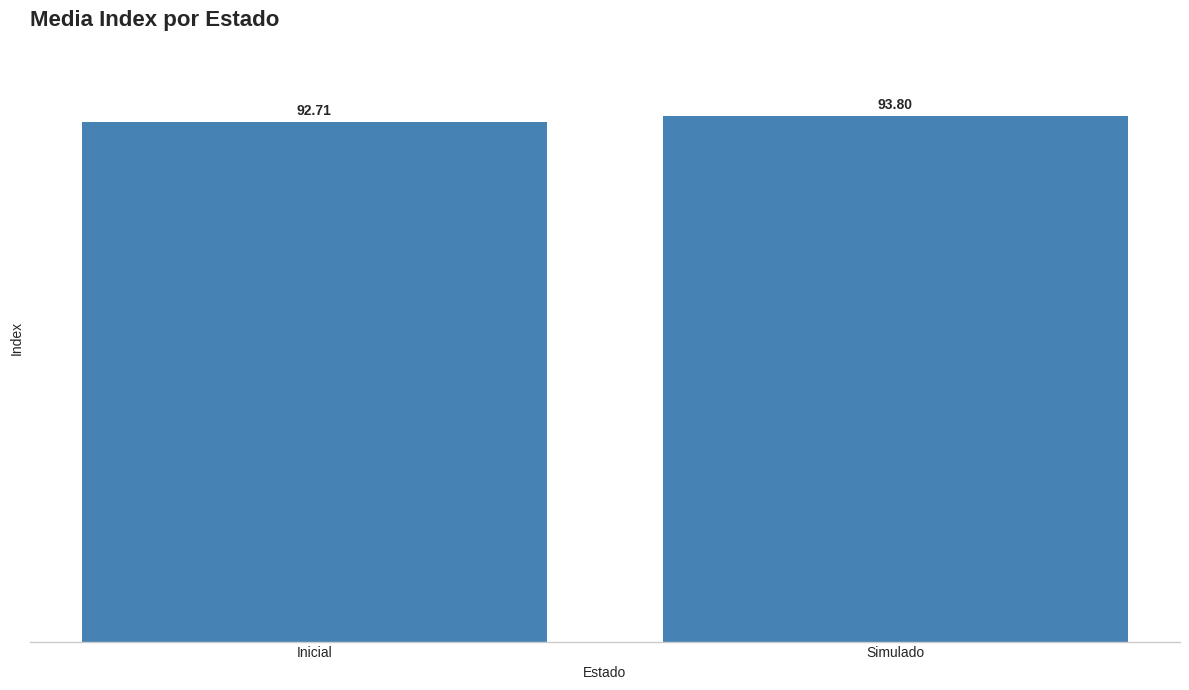

In [24]:
plt.style.use('seaborn-v0_8-whitegrid')

mean_index = (
    df.groupby("Estado")["Index"]
    .mean()
    .reindex(["Inicial", "Simulado"])
)

fig_mean_index, ax = plt.subplots(figsize=(12, 7))

ax.grid(False)

bars = ax.bar(
    mean_index.index,
    mean_index.values,
    color='#4682B4'
)

# Etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Título y ejes (mismo estilo que los otros)
ax.set_title(
    "Media Index por Estado",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

ax.set_ylabel("Index")
ax.set_xlabel("Estado")

# Limpieza visual consistente
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Ocultar números del eje Y (igual que los otros)
ax.tick_params(axis='y', labelleft=False)

# Ajuste para etiquetas
ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.savefig('fig_mean_index.png')
plt.show()

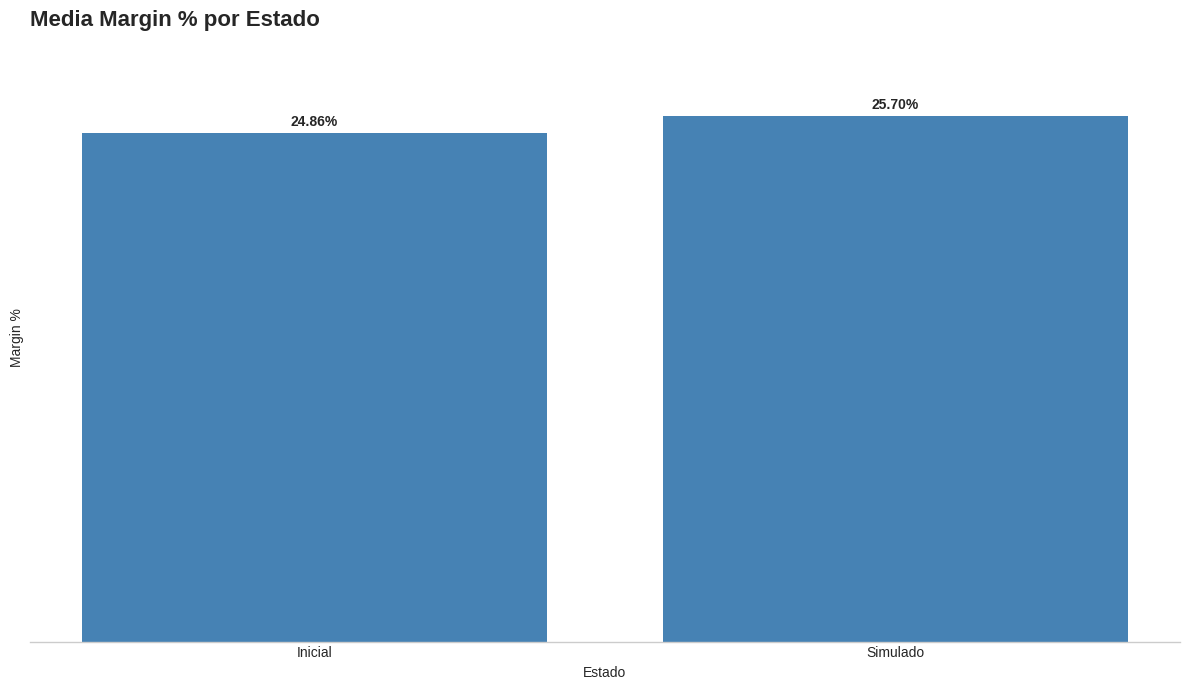

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')

mean_margin = (
    df.groupby("Estado")["Margin %"]
    .mean()
    .reindex(["Inicial", "Simulado"])
)

fig_mean_margin, ax = plt.subplots(figsize=(12, 7))

ax.grid(False)

bars = ax.bar(
    mean_margin.index,
    mean_margin.values*100,
    color='#4682B4'
)

# Etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f}%',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Título y ejes (consistente con el resto)
ax.set_title(
    "Media Margin % por Estado",
    fontsize=16,
    fontweight='bold',
    loc='left'
)

ax.set_ylabel("Margin %")
ax.set_xlabel("Estado")

# Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Ocultar eje Y (misma regla que los otros gráficos)
ax.tick_params(axis='y', labelleft=False)

# Ajuste para etiquetas
ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.savefig('fig_mean_margin.png')
plt.show()

/tmp/ipykernel_1292/2097153646.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


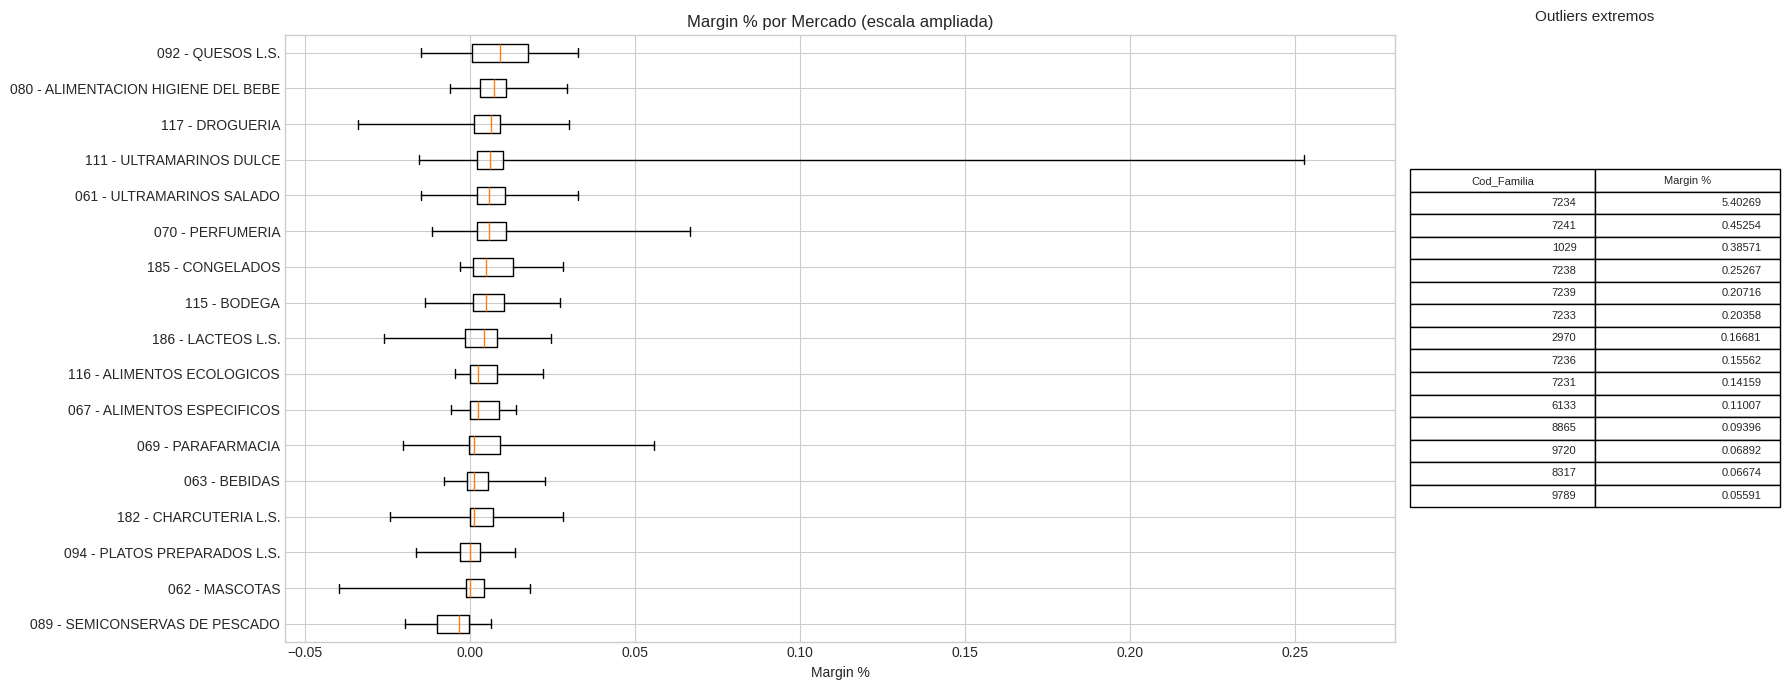

In [26]:

# =========================
# OUTLIERS
# =========================

def obtener_outliers(df_in, variable):
    q1 = df_in[variable].quantile(0.25)
    q3 = df_in[variable].quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    return df_in[
        (df_in[variable] < lim_inf) |
        (df_in[variable] > lim_sup)
    ].copy()


# =========================
# DATASET
# =========================

df_familia = datos[
    (datos["Estado"] == "Brecha") &
    (datos["Familia"].notna()) &
    (datos["Margin %"].notna())
].copy()

df_familia["Cod_Familia"] = (
    df_familia["Familia"]
    .astype(str)
    .str.extract(r"^(\d+)")
)

# =========================
# ORDENAR MERCADOS
# =========================

orden = (
    df_familia
    .groupby("Mercado")["Margin %"]
    .median()
    .sort_values()
    .index
)

mercados = list(orden)

# =========================
# DATOS PARA BOXPLOT + OUTLIERS
# =========================

data = []
outliers_all = []

for mercado in mercados:
    sub = df_familia[df_familia["Mercado"] == mercado]

    # datos para boxplot (IMPORTANTE)
    data.append(sub["Margin %"].dropna().values)

    # outliers
    out = obtener_outliers(sub, "Margin %")
    out["Mercado"] = mercado
    outliers_all.append(out)

# =========================
# OUTLIERS GLOBAL
# =========================

if outliers_all:
    outliers_all = pd.concat(outliers_all, ignore_index=True)
else:
    outliers_all = pd.DataFrame(columns=df_familia.columns.tolist() + ["Mercado"])

threshold = df_familia["Margin %"].quantile(0.99)

outliers_extremos = outliers_all[
    outliers_all["Margin %"] > threshold
].sort_values("Margin %", ascending=False)

# =========================
# ESCALA
# =========================

lim_inf = df_familia["Margin %"].quantile(0.002)
lim_sup = df_familia["Margin %"].quantile(0.998)

# =========================
# FIGURA
# =========================

fig_marg_box_cat = plt.figure(figsize=(18, 7))
gs = fig_marg_box_cat.add_gridspec(1, 2, width_ratios=[4.5, 1.5])

ax = fig_marg_box_cat.add_subplot(gs[0])
ax_table = fig_marg_box_cat.add_subplot(gs[1])

# =========================
# BOXPLOT (CORREGIDO)
# =========================

ax.boxplot(
    data,
    labels=mercados,   # <-- CORRECTO (NO tick_labels)
    vert=False,
    showfliers=False,
    whis=(1, 99),
    widths=0.5
)

ax.set_xlim(lim_inf, lim_sup)
ax.set_title("Margin % por Mercado (escala ampliada)")
ax.set_xlabel("Margin %")
ax.margins(y=0.02)

# =========================
# TABLA OUTLIERS
# =========================

ax_table.axis("off")

tabla = outliers_extremos[["Cod_Familia", "Margin %"]]

table = ax_table.table(
    cellText=tabla.values,
    colLabels=tabla.columns,
    loc="center"
)

ax_table.set_title("Outliers extremos", fontsize=11, pad=10)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.2)

# =========================
# FINAL
# =========================

plt.tight_layout()
plt.savefig('fig_marg_box_cat.png')
plt.show()

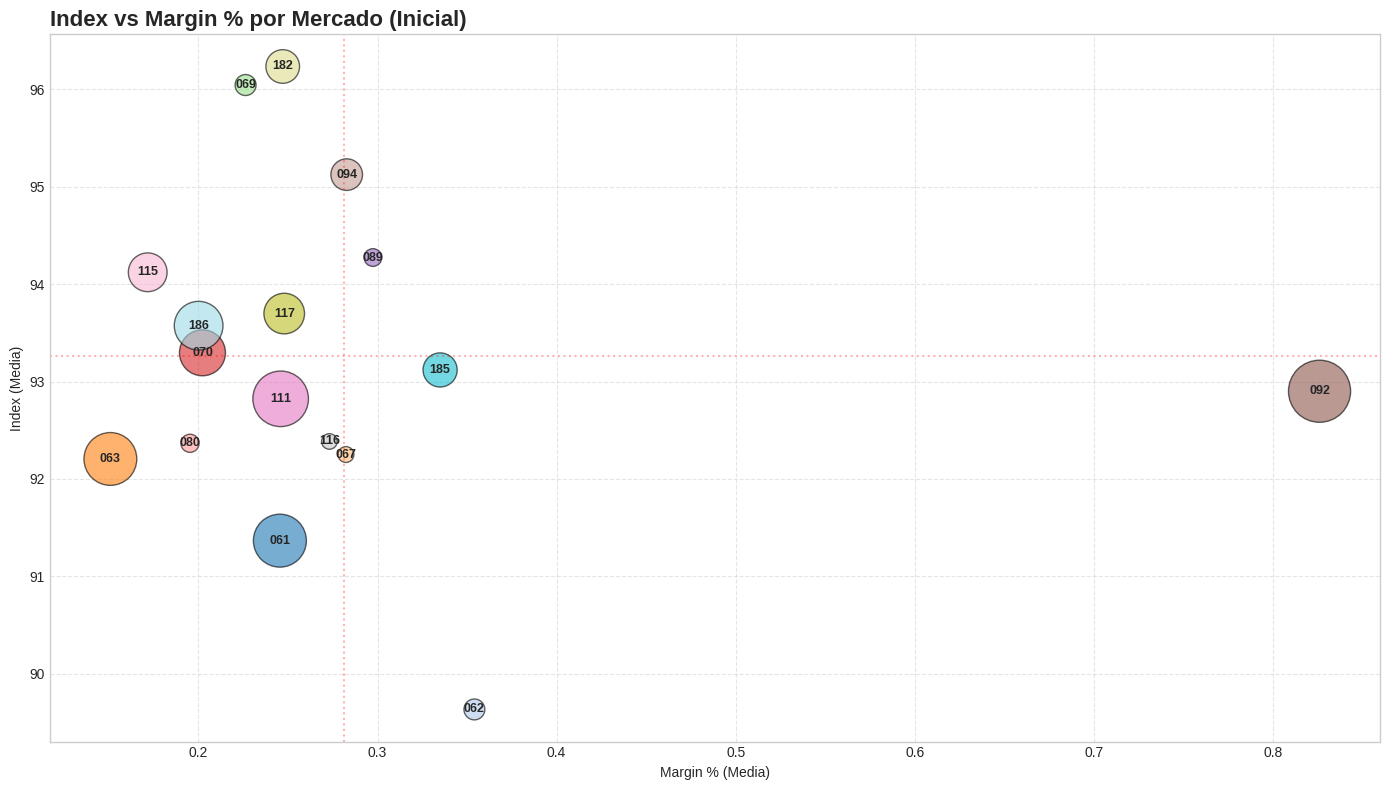

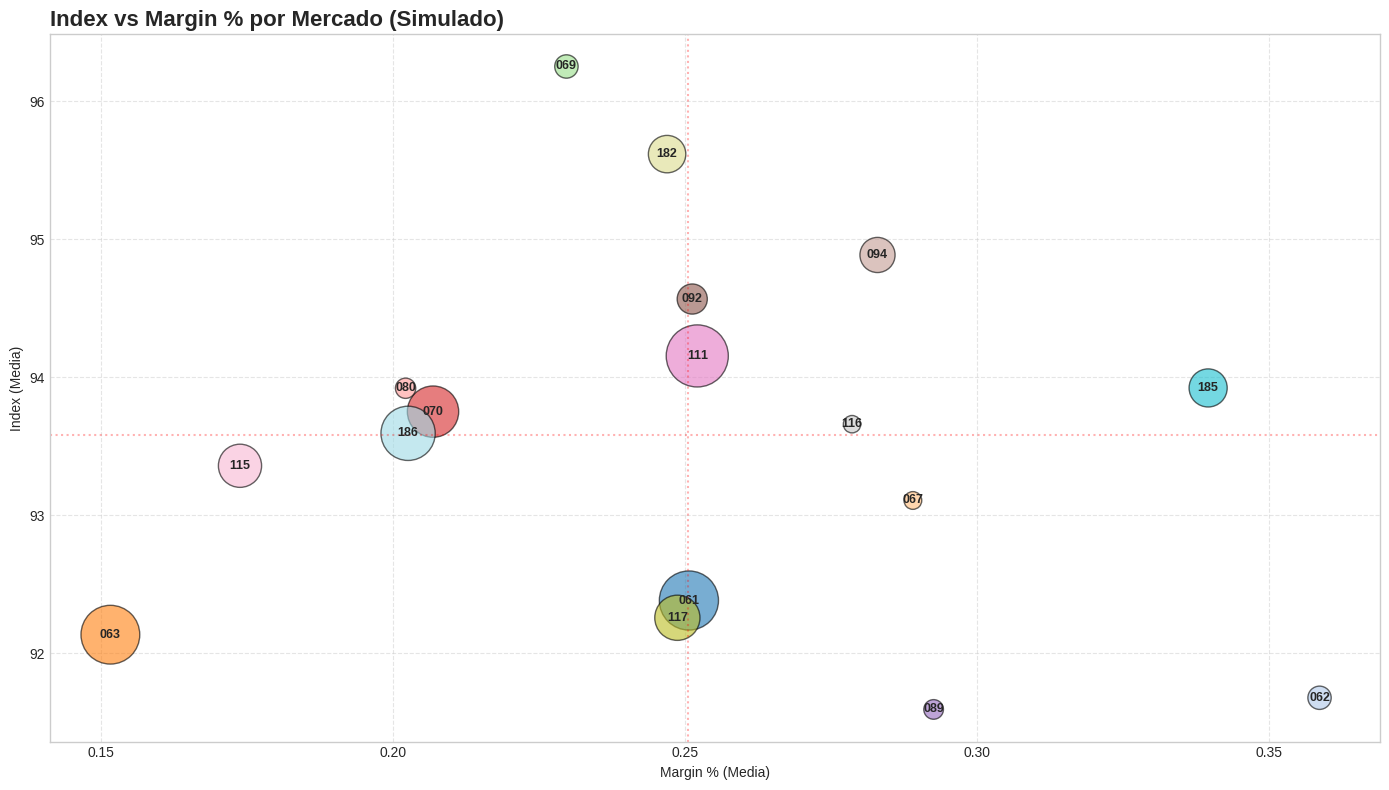

In [27]:
def crear_grafico_burbujas(df, estado):
    """
    Genera un gráfico de burbujas (Index vs. Margin %) para un estado específico.
    """
    df_estado = (
        df[df["Estado"] == estado]
        .groupby("Mercado")
        .agg({"Margin %": "mean", "Index": "mean", "Sales": "sum"})
        .reset_index()
    )

    if df_estado.empty:
        print(f"No hay datos para el estado '{estado}'.")
        return None

    df_estado["Market Code"] = df_estado["Mercado"].astype(str).str.extract(r"^(\d{3})")[0].fillna(df_estado["Mercado"])
    max_sales = df_estado["Sales"].abs().max()
    df_estado["Size" ] = (df_estado["Sales"].abs() / max_sales) * 2000 if max_sales > 0 else 500

    fig, ax = plt.subplots(figsize=(14, 8))
    scatter = ax.scatter(
        df_estado["Margin %"],
        df_estado["Index"],
        s=df_estado["Size"],
        c=np.arange(len(df_estado)),
        cmap='tab20',
        alpha=0.6,
        edgecolors="black"
    )

    for _, row in df_estado.iterrows():
        ax.text(row["Margin %"], row["Index"], row["Market Code"], ha='center', va='center', fontsize=9, fontweight='bold')

    ax.set_title(f"Index vs Margin % por Mercado ({estado})", fontsize=16, fontweight='bold', loc='left')
    ax.set_xlabel("Margin % (Media)")
    ax.set_ylabel("Index (Media)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(df_estado["Index"].mean(), color='red', linestyle=':', alpha=0.3)
    ax.axvline(df_estado["Margin %"].mean(), color='red', linestyle=':', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'fig_{estado.lower()}_bubble.png')
    plt.show()
    return fig

fig_inicial = crear_grafico_burbujas(kpis, "Inicial")
fig_simulado = crear_grafico_burbujas(kpis, "Simulado")

In [28]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "dashboard_kpis.pdf"

with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig_index_pos)
    pdf.savefig(fig_neg_margin)
    pdf.savefig(fig_sales_merc)
    pdf.savefig(fig_mean_index)
    pdf.savefig(fig_mean_margin)
    pdf.savefig(fig_marg_box_cat)
    pdf.savefig(fig_inicial)
    pdf.savefig(fig_simulado)

print(f"PDF generado: {pdf_path}")

PDF generado: dashboard_kpis.pdf


In [29]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# Abrir Excel
wb = load_workbook(excel_file)

# Recrear hoja Dashboard
if "Dashboard" in wb.sheetnames:
    del wb["Dashboard"]

ws = wb.create_sheet("Dashboard")


# ---------- CONFIG ----------
IMG_WIDTH = 420          # tamaño uniforme
ROW_STEP = 28            # separación vertical entre bloques
START_ROWS = [1, 30, 60] # filas base por bloques


# ---------- FUNCIÓN ----------
def add_img(ws, path, cell, width=IMG_WIDTH):
    img = Image(path)

    # mantener proporción
    ratio = img.height / img.width
    img.width = width
    img.height = width * ratio

    ws.add_image(img, cell)


# ---------- LAYOUT DASHBOARD ----------
images = [
    ("/content/fig_index_pos.png", "A1"),
    ("/content/fig_neg_margin.png", "J1"),
    ("/content/fig_sales_merc.png", "A30"),
    ("/content/fig_mean_index.png", "J30"),
    ("/content/fig_mean_margin.png", "A60"),
    ("/content/fig_marg_box_cat.png", "J60"),
    ("/content/fig_inicial_bubble.png", "A88"), # Added bubble chart for Inicial state
    ("/content/fig_simulado_bubble.png", "J88")  # Added bubble chart for Simulado state
]


# Insertar imágenes
for path, cell in images:
    add_img(ws, path, cell)


# ---------- ESPACIADO VISUAL ----------
# (esto evita que Excel “encime” contenido visualmente)
for r in range(1, 100):
    ws.row_dimensions[r].height = 18

ws.column_dimensions["A"].width = 55
ws.column_dimensions["J"].width = 55


# Guardar
wb.save(excel_file)